In [2]:
# Loading Dataset
import pandas as pd


df = pd.read_csv("bank.csv")

X = df.drop('deposit', axis=1)
y = df['deposit']

# print(df.info())

for col in X.select_dtypes(include='object').columns:
    print(col, df[col].unique())
    print()

job <StringArray>
[       'admin.',    'technician',      'services',    'management',
       'retired',   'blue-collar',    'unemployed',  'entrepreneur',
     'housemaid',       'unknown', 'self-employed',       'student']
Length: 12, dtype: str

marital <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str

education <StringArray>
['secondary', 'tertiary', 'primary', 'unknown']
Length: 4, dtype: str

default <StringArray>
['no', 'yes']
Length: 2, dtype: str

housing <StringArray>
['yes', 'no']
Length: 2, dtype: str

loan <StringArray>
['no', 'yes']
Length: 2, dtype: str

contact <StringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str

month <StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

poutcome <StringArray>
['unknown', 'other', 'failure', 'success']
Length: 4, dtype: str



C:\Users\User\AppData\Local\Temp\ipykernel_25512\841808337.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


In [3]:
# Class Imbalance

class_count = df['deposit'].value_counts()
class_percentage = df['deposit'].value_counts(normalize=True) * 100

distribution_table = pd.DataFrame({
    'Class' : class_count,
    'Percentage' : class_percentage.round(2)
})

print(distribution_table)

         Class  Percentage
deposit                   
no        5873       52.62
yes       5289       47.38


In [4]:
# Split data with 80/20 ratio
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
# Pipeline & Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier


print(df.info())

categorical_cols = X.select_dtypes(include='object').columns.to_list()
preprocess = ColumnTransformer(
    transformers = [
        ('encode_data', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB
None


C:\Users\User\AppData\Local\Temp\ipykernel_25512\1558007959.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.to_list()


In [7]:
# Finding the best settings for the model (DecisionTreeClassifier)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__class_weight' : ['balanced', None],
    'model__max_depth' : [3, 5, 7, 10],
    'model__min_samples_split' : [2, 5, 10, 20],
    'model__min_samples_leaf' : [1, 2, 4, 8]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [8]:
# Train model

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', None], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Su

In [9]:
predictions = grid_search.predict(X_test)

print(predictions)

['yes' 'yes' 'yes' ... 'yes' 'yes' 'yes']


In [16]:
# Training accuracy and Testing accuracy

train_accuracy = grid_search.score(X_train, y_train)
test_accuracy = grid_search.score(X_test, y_test)

print(f"Training Accuracy : {round(train_accuracy, 4)*100}")
print(f"Testing Accuracy : {round(test_accuracy, 4)*100}")

print(grid_search.best_params_)

Training Accuracy : 83.96000000000001
Testing Accuracy : 81.77
{'model__class_weight': 'balanced', 'model__max_depth': 7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}


In [10]:
# Classification Report and Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

              precision    recall  f1-score   support

          no       0.85      0.79      0.82      1175
         yes       0.78      0.85      0.82      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



Confusion Matrix
[[926 249]
 [158 900]]


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encode_data',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=7,
                                        min_samples_split=5,
                                        random_state=42))])


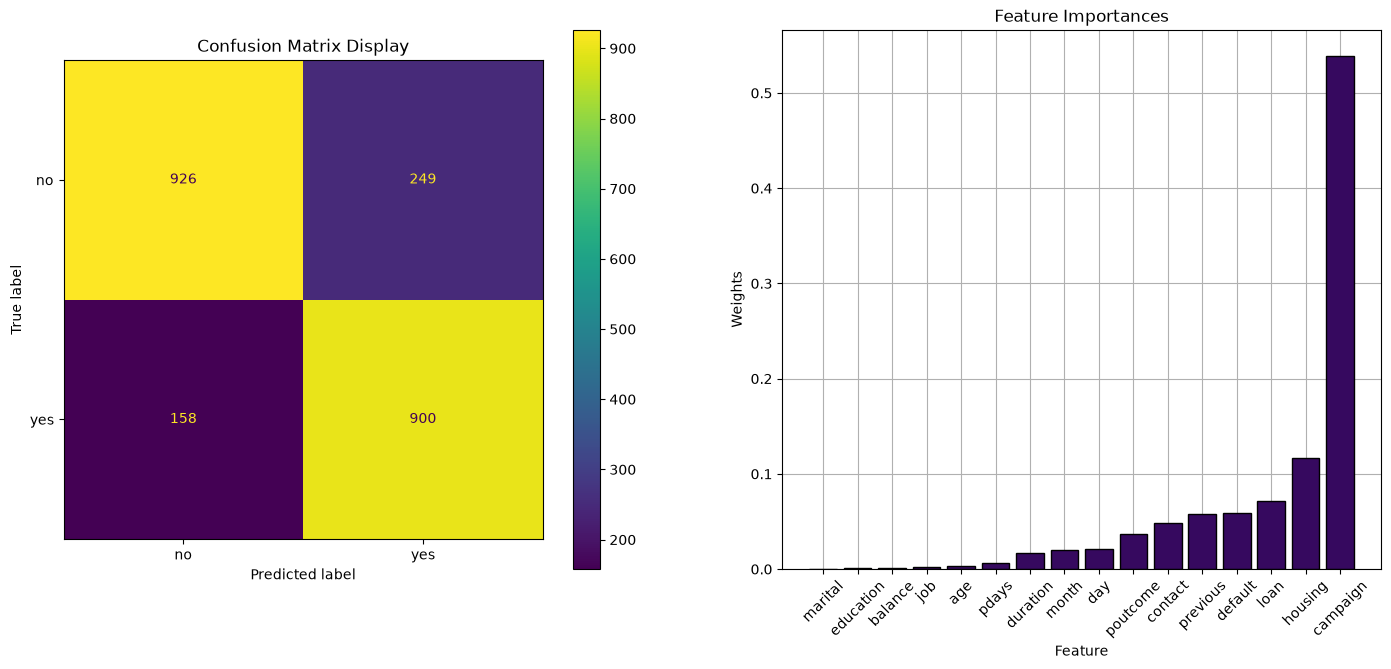

In [11]:
# Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix Display")

# Feature Importance
best_estimator = grid_search.best_estimator_
print(best_estimator)
model = best_estimator.named_steps['model']
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

axes[1].bar(importances.index, importances.values, edgecolor='#000000', color="#36095F")
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Weights")
axes[1].grid(True)
axes[1].set_axisbelow(True)
axes[1].tick_params(axis='x', rotation=45)

[Text(0.5, 0.9, 'campaign <= 206.5\ngini = 0.5\nsamples = 8929\nvalue = [4464.5, 4464.5]\nclass = Will subscribe'),
 Text(0.25, 0.7, 'campaign <= 129.5\ngini = 0.346\nsamples = 3646\nvalue = [2753.964, 789.281]\nclass = Will not subscribe'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'campaign <= 77.5\ngini = 0.198\nsamples = 2054\nvalue = [1754.25, 219.479]\nclass = Will not subscribe'),
 Text(0.0625, 0.3, 'loan <= 3.5\ngini = 0.058\nsamples = 920\nvalue = [850.517, 26.38]\nclass = Will not subscribe'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'loan <= 9.5\ngini = 0.29\nsamples = 1134\nvalue = [903.733, 193.099]\nclass = Will not subscribe'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'previous <= 9.5\ngini = 0.462\nsamples = 1592\nvalue = [999.713, 569.801]\nclass = Will not subscribe'),
 Text(0.3125, 0.3, 'loan <= 9.5\ngini = 0.377\nsamples = 1175\nvalue = [856.218, 289.121]\

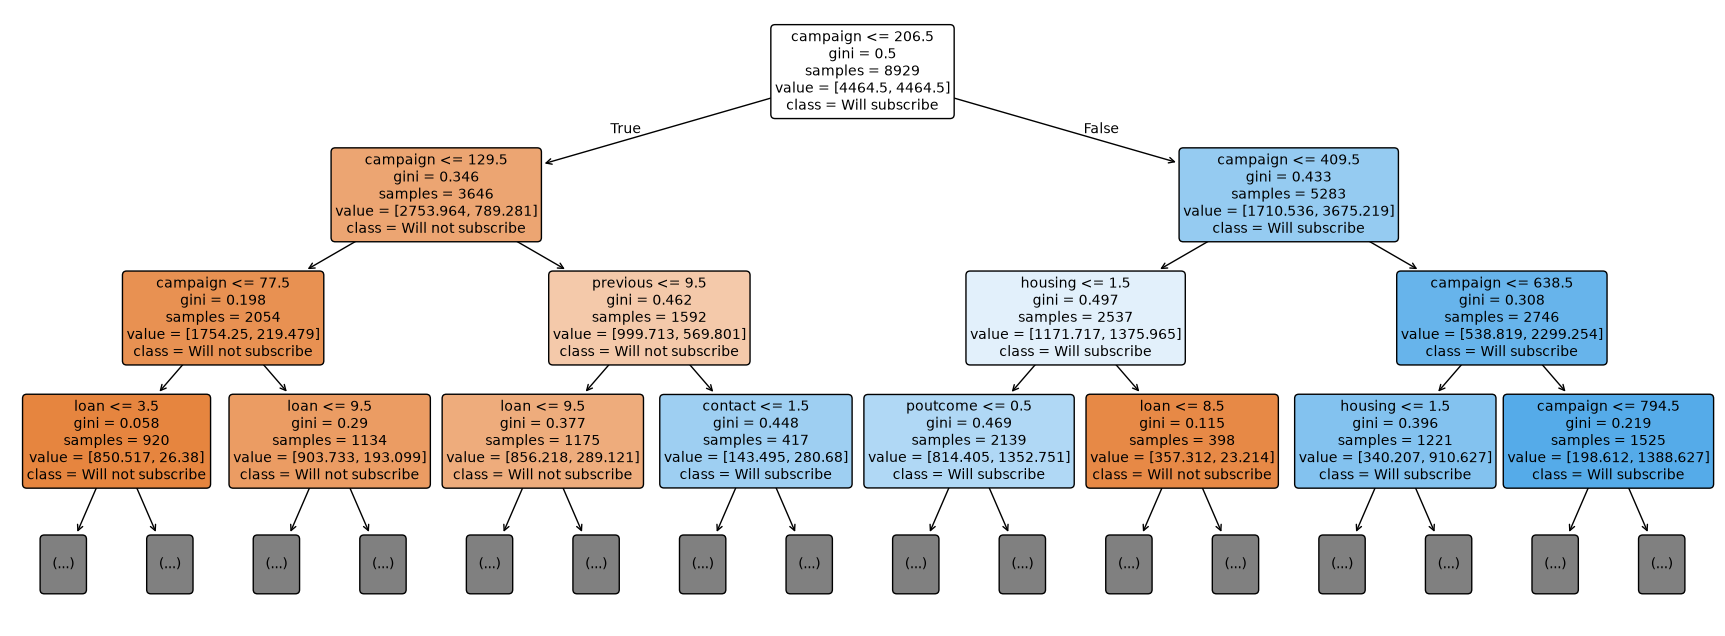

In [12]:
# Tree Structure
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 8))

plot_tree(
    model,
    max_depth = 3,
    feature_names = X.columns,
    class_names = ['Will not subscribe', 'Will subscribe'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax = ax
)